In [33]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv")



### Task 1


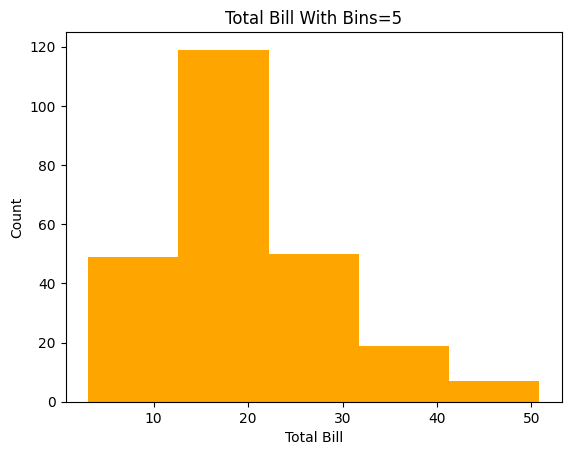

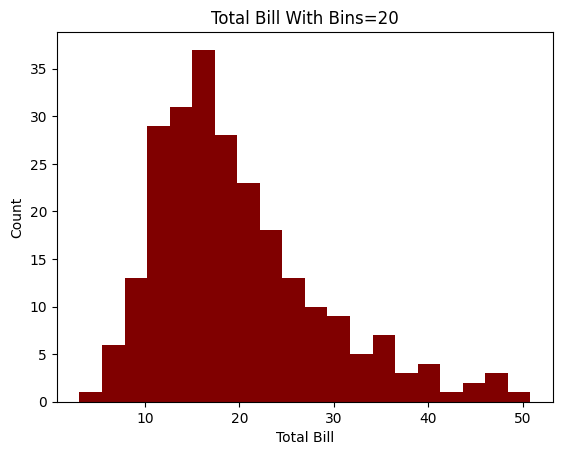

In [34]:
plt.hist(df["total_bill"], bins=5, color="orange")

plt.title("Total Bill With Bins=5")
plt.xlabel("Total Bill")
plt.ylabel("Count")
plt.show()

plt.hist(df["total_bill"], bins=20, color="maroon")

plt.title("Total Bill With Bins=20")
plt.xlabel("Total Bill")
plt.ylabel("Count")
plt.show()



1. The total bill is right-skewed. Since there are low number of high value bills, the graph is a right-skewed graph.
2. When the bins count is increased to 20, we can finer details in the distribution. We can clearly observe that the graph peaks at around 18 and then slowly decreases. Whereas, from the graph with 5 bins, it seems that there is a sudden drop which is not accurate.

### Task 2

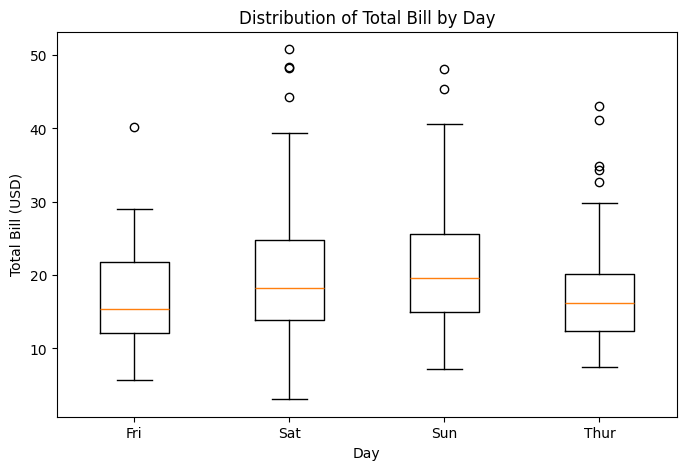

Q1 Sat: 13.9
Q2 Sat: 18.24
Q3 Sat: 24.74
IQR Sat: 10.84
Outliers Sat:      total_bill
59        48.27
102       44.30
142       41.19
156       48.17
170       50.81
182       45.35
197       43.11
212       48.33


In [35]:
days = np.unique(df["day"])
data = [df[df['day'] == day]['total_bill'] for day in days]
plt.figure(figsize=(8, 5))
plt.boxplot(data)

plt.xticks(range(1, len(days) + 1), days)
plt.xlabel('Day')
plt.ylabel('Total Bill (USD)')
plt.title('Distribution of Total Bill by Day')
plt.show()

total_bill_by_day = df.groupby('day')["total_bill"]

chosen_day = "Sat"
q1 = total_bill_by_day.quantile(0.25)
q2 = total_bill_by_day.quantile(0.5)
q3 = total_bill_by_day.quantile(0.75)

iqr = q3 - q1 

outlier_min = q1 - 1.5 * iqr
outlier_max = q3 + 1.5 * iqr

outliers = df[(df['total_bill'] <= outlier_min[chosen_day]) | (df['total_bill'] >= outlier_max[chosen_day])][["total_bill"]]

print(f"Q1 {chosen_day}: {round(q1[chosen_day], 2)}")
print(f"Q2 {chosen_day}: {round(q2[chosen_day],2)}")
print(f"Q3 {chosen_day}: {round(q3[chosen_day],2)}")
print(f"IQR {chosen_day}: {round(iqr[chosen_day],2)}")
print(f"Outliers {chosen_day}: {outliers}")





#### Answers
1. The median bill appears the highest on Sunday.
2. All the points calculated above are outliers on saturday. We can also see the same points on the graph.

### Task 3

In [36]:

hover_dict = {col: False for col in df.columns}
hover_dict["day"] = True
hover_dict["size"] = True
    
fig = px.scatter(df,x= "total_bill",y="tip", color="time", hover_data=hover_dict, title="Tips vs Total Bill")
fig.show()

#### Answers
1. The tips seem to be increasing on average as the total bill increases. This can be observed by seeing the above graph, where the highest tip is given for the highest total bill.
2. The variability of tips in dinner bills is higher, whereas the tips in lunch bills are less spread out comparitively. Also, the lunch bills are concentrated in the lower total bill ranges. This shows that people are less likely to spend more on their lunch.
3. The one standout point for me is the one at around $8 bill with $8 tip. The tip value here is very close to the total bill and appears very generous compared to others.